Centering and scaling data matrix

Quantiles for the number of genes detected by cell: 
(Non-detected genes are shuffled at the end of the ranking. Keep it in mind when choosing the threshold for calculating the AUC).



     min       1%       5%      10%      50%     100% 
  518.00  1488.32  1774.80  1959.00  2899.00 16008.00 


Warning message:
“useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE.”
Warning message:
“useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE.”
Warning message:
“useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE.”
Warning message:
“useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE.”
Warning message:
“useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE.”
Warning message:
“useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE.”
Warning message:
“useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE.”
Genes in the gene sets NOT available in the dataset: 
	Negative Regulation of Cell Adhesion: 	1 (7% of 15)
	Glycolipid Metabolic Process: 	1 (7% of 15)
	Cell-Cell Adhesion Via Plasma-Membrane Adhesion Molecules: 	1 (8% of 12)
	Negative R

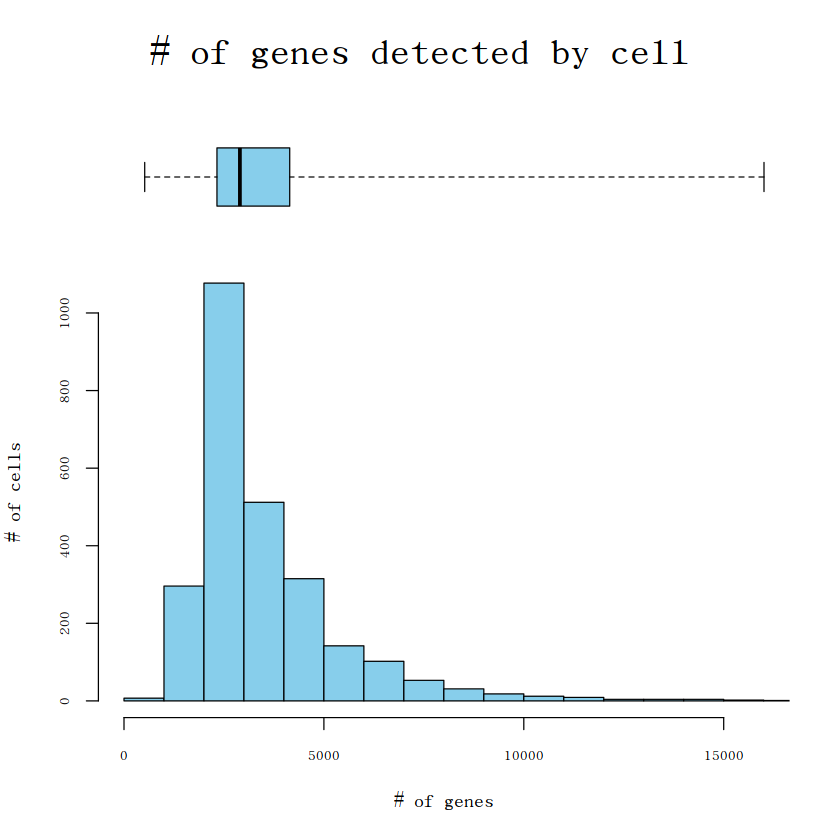

In [3]:
library(Seurat)
library(AUCell)


RNA_count <- Matrix::readMM("./ComicGTN_reproducibility/Data/ARPKD_kideny_organoid/GLOM_type/GLOM_Gene_Cell.mtx")
Gene_names <- read.csv("./ComicGTN_reproducibility/Data/ARPKD_kideny_organoid/GLOM_type/GLOM_gene_names.tsv", header = FALSE, sep = ",")
Cell_names <- read.table("./ComicGTN_reproducibility/Data/ARPKD_kideny_organoid/GLOM_type/GLOM_cell_names.tsv", header = FALSE, sep = ",")
Cell_types <- read.table("./ComicGTN_reproducibility/Data/ARPKD_kideny_organoid/GLOM_type/GLOM_cell_types.tsv", header = FALSE, sep = ",")


RNA_count <- as(RNA_count, "dgCMatrix")
colnames(RNA_count) <- Cell_names$V1
rownames(RNA_count) <- Gene_names$V1
rownames(Cell_types) <- Cell_names$V1
rownames(Gene_names) <- Gene_names$V1
names(Gene_names)<-c("gene_short_name")


GLOM_cluster <- CreateSeuratObject(counts = RNA_count)
GLOM_cluster$cell_types <- Cell_types$V1
GLOM_cluster<- NormalizeData(GLOM_cluster, normalization.method = "LogNormalize", scale.factor = 10000)
GLOM_cluster <- FindVariableFeatures(GLOM_cluster, selection.method = "vst", nfeatures = 2000)
GLOM_cluster <- ScaleData(GLOM_cluster, features = VariableFeatures(GLOM_cluster))
exprMatrix <- GLOM_cluster@assays$RNA@counts
cell_ranking <- AUCell_buildRankings(exprMatrix, plotStats = TRUE)


GOGeneList <- list("Negative Regulation of Cell Adhesion" = c("PODXL", "PTPRO", "CORO2B", "PAG1", "WNT1", "PRKCD", "FBLN1", "LILRB2",
                                                                                                      "EPCAM", "CTLA4", "SHH", "MAPK7", "CBLL1", "TIGIT", "MYADM"),
                                "Glycosaminoglycan Biosynthetic Process" = c("GCNT2", "B3GAT3", "HAS1", "HAS2", "HAS3", "HS3ST1", "ABCC5", "B3GALT6", 
                                                                                                           "HS3ST3A1", "ST3GAL6", "ST3GAL1", "XYLT2", "EXT2"),
                                "Keratan Sulfate Biosynthetic Process" = c("B4GALT4", "B3GNT2", "CHST5", "CHST6", "ST3GAL1", "ST3GAL6"),
                                "Glycolipid Metabolic Process" = c("HEXA", "PIGO", "NEU4", "UGT8", "ST6GALNAC5", "PIGB", "PIGC", "ABCA2", "PIGX", 
                                                                                        "DPM1", "GLB1", "GLA", "GBA1", "ST3GAL6", "ST6GALNAC3"),
                                "Glomerular Filtration" = c("KIRREL1", "NPHS2", "RHPN2", "AQP1", "SULF1", "SULF2", "ADGRF5", "MCAM", "CD34", "UMOD"),
                                "Cellular Response To Decreased Oxygen Levels" = c("BMP7", "HIPK2", "CPEB4", "RPTOR", "SFRP1", "EEF2K", "EPAS1", "HIF1A",
                                                                                                                      "SLC8A3", "TERT", "GATA6", "CLCA1", "AK4", "BNIP3", "MTOR"),
                                "Cell-Cell Adhesion Via Plasma-Membrane Adhesion Molecules" = c("CDH6", "PTPRD", "CNTN4", "CEACAM5", "CADM3", 
                                                                                                                                               "ROBO4", "NLGN1", "CD177", "NECTIN1", "SELE", 
                                                                                                                                               "CEACAM6", "CDH17"),
                                "Negative Regulation of Cell Population Proliferation" = c("TGFBR3", "WT1", "MAGI2", "P3H2", "IGFBP7", "NRG1", "SMAD6", 
                                                                                                                              "RERG", "ZBTB7C", "BTG2", "NTRK1", "SFRP1", "LILRB2", "CTLA4"),
                                "Adherens Junction Organization" = c("CDH6", "TJP1", "CDH1", "TBCD", "RAMP2", "KIFC3", "VCL", "DLG5", "PLEC", "DSG3",
                                                                                             "JAM3", "CDH5", "SMAD7", "PAK2", "CTNNB1"),
                                "Notch Signaling Pathway" = c("NOTCH2", "GMDS", "MAML3", "ADAM17", "TIMP4", "SIX1", "PLN", "FOXC2", "DLL1", "APH1B",
                                                                                   "CNTN1", "MAML2", "MESP1", "NOTCH4", "HES5", "DLL3", "NLE1", "NRARP", "HES1"))
GOGeneSet <- c()
GeneSet <- function(x, setName){
    l <- list(x) 
    names(l) <- setName 
    return(l)}

for(i in 1:length(GOGeneList)){
    GOGeneSet <- c(GOGeneSet, GeneSet(GOGeneList[[i]], setName = names(GOGeneList)[i]))}


cell_AUC <- AUCell_calcAUC(GOGeneSet, cell_ranking)
AUCell_auc1 <- round(as.numeric(getAUC(cell_AUC)["Negative Regulation of Cell Adhesion", ]), digits = 6)
AUCell_auc2 <- round(as.numeric(getAUC(cell_AUC)["Glycosaminoglycan Biosynthetic Process", ]), digits = 6)
AUCell_auc3 <- round(as.numeric(getAUC(cell_AUC)["Keratan Sulfate Biosynthetic Process", ]), digits = 6)
AUCell_auc4 <- round(as.numeric(getAUC(cell_AUC)["Glycolipid Metabolic Process", ]), digits = 6)
AUCell_auc5 <- round(as.numeric(getAUC(cell_AUC)["Glomerular Filtration", ]), digits = 6)
AUCell_auc6 <- round(as.numeric(getAUC(cell_AUC)["Cellular Response To Decreased Oxygen Levels", ]), digits = 6)
AUCell_auc7 <- round(as.numeric(getAUC(cell_AUC)["Cell-Cell Adhesion Via Plasma-Membrane Adhesion Molecules", ]), digits = 6)
AUCell_auc8 <- round(as.numeric(getAUC(cell_AUC)["Negative Regulation of Cell Population Proliferation", ]), digits = 6)
AUCell_auc9 <- round(as.numeric(getAUC(cell_AUC)["Adherens Junction Organization", ]), digits = 6)
AUCell_auc10 <- round(as.numeric(getAUC(cell_AUC)["Notch Signaling Pathway", ]), digits = 6)
AUCell_df <- data.frame("Negative Regulation of Cell Adhesion" = AUCell_auc1, 
                                        "Glycosaminoglycan Biosynthetic Process" = AUCell_auc2,
                                        "Keratan Sulfate Biosynthetic Process" = AUCell_auc3,
                                        "Glycolipid Metabolic Process" = AUCell_auc4,
                                        "Glomerular Filtration" = AUCell_auc5,
                                        "Cellular Response To Decreased Oxygen Levels" = AUCell_auc6,
                                        "Cell-Cell Adhesion Via Plasma-Membrane Adhesion Molecules" = AUCell_auc7, 
                                        "Negative Regulation of Cell Population Proliferation" = AUCell_auc8, 
                                        "Adherens Junction Organization" = AUCell_auc9, 
                                        "Notch Signaling Pathway" = AUCell_auc10, check.names = FALSE)
write.csv(AUCell_df, file = "./ComicGTN_reproducibility/Data/ARPKD_kideny_organoid/GLOM_type/AUCell_score.csv", row.names = FALSE)

In [34]:
library(UpSetR)
library(dplyr)
library(tidyr)
library(ggplot2)
library(plyr)
library(gridExtra) 
library(grid)


input <- c("GLOM3" = 426,"GLOM4" = 271,"GLOM3&GLOM4" = 152)
data <- fromExpression(input)
png("./ComicGTN_reproducibility/Data/ARPKD_kideny_organoid/Upset1.png", width = 4800, height = 3600, res = 600)
upset(data, sets = c("GLOM4", "GLOM3"), mb.ratio = c(0.7, 0.3), order.by = "freq", keep.order = TRUE,
          point.size = 7, line.size = 1, mainbar.y.label = "Intersection Size", sets.x.label = "Genes Per Cluster",
          main.bar.color = "#808080", sets.bar.color ="#808080", matrix.color = "#DC143C",
          scale.sets = "identity", text.scale = c(2.0, 1.5, 1.5, 1.5, 2.5, 2.0))
dev.off()


input <- c("GLOM3" = 1882,"GLOM4" = 1196,"GLOM3&GLOM4" = 694)
data <- fromExpression(input)
png("./ComicGTN_reproducibility/Data/ARPKD_kideny_organoid/Upset2.png", width = 4800, height = 3600, res = 600)
upset(data, sets = c("GLOM4", "GLOM3"), mb.ratio = c(0.7, 0.3), order.by = "freq", keep.order = TRUE,
          point.size = 7, line.size = 1, mainbar.y.label = "Intersection Size", sets.x.label = "Region Per Cluster",
          main.bar.color = "#808080", sets.bar.color ="#808080", matrix.color = "#DC143C",
          scale.sets = "identity", text.scale = c(2.0, 1.5, 1.5, 1.5, 2.5, 2.0))
dev.off()

png 
  2